In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Data Manipulation
import numpy as np
import pandas as pd

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.utils import shuffle

# Plotting library
import plotly.express as px

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
datasets = ['17.36N_78.5E', '18N_283.2E', '-33.5N_151E',
            '-33.9N_18.5E', '40.75N_286.01E', '41.9N_12.46E',
            '43.28N_5.39E', '43.64N_280.63E', '51.03N_245.94E',
            '51.5N_359.9E', '58.76N_265.83E', '59.92N_10.75E']

lats = ["17.36", "18", "-33.5", "-33.9", "40.75", "41.9", "43.28", "43.64", "51.03",
        "51.5", "58.76", "59.92"]

lons = ["78.5", "-76.8", "151", "18.5", "-73.99", "12.46", "5.39", "-79.37", "-114.06",
        "-0.1", "-94.17", "10.75"]

columns = ['Year', 'Month', 'Day', 'Hour', 'Temperature', 'Precipitation',
           'U-Wind', 'V-Wind']

locations = ['Hyderabad-India', 'Kingston-Jamaica', 'Maroota-Australia',
             'Milnerton-South_Africa', 'New_York-USA', 'Rome-Italy',
             'Marseille-France', 'Ontario-Canada', 'Calgary-Canada',
             'London-UK', 'Churchill-Canada', 'Oslo-Norway']

dfWeather = []

# Append datasets to each other and add location column
for i in range(len(datasets)):
    tempDf = pd.read_csv("/content/drive/MyDrive/ADS_CW_Data/weather_data/"+datasets[i]+".csv", names=columns)
    tempDf["Location"] = locations[i]
    tempDf["Latitude"] = lats[i]
    tempDf["Longitude"] = lons[i]

    dfWeather.append(tempDf)

dfWeather = pd.concat(dfWeather, ignore_index=True)

display(dfWeather)

,Year,Month,Day,Hour,Temperature,Precipitation,U-Wind,V-Wind,Location,Latitude,Longitude
0,1980,1,1,0,290.74,0.000000e+00,-0.063355,2.8181,Hyderabad-India,17.36,78.5
1,1980,1,1,1,290.84,0.000000e+00,0.038482,2.4318,Hyderabad-India,17.36,78.5
2,1980,1,1,2,291.94,0.000000e+00,0.538340,2.2221,Hyderabad-India,17.36,78.5
3,1980,1,1,3,296.55,0.000000e+00,1.049000,2.2748,Hyderabad-India,17.36,78.5
4,1980,1,1,4,297.44,0.000000e+00,1.115400,2.7555,Hyderabad-India,17.36,78.5
...,...,...,...,...,...,...,...,...,...,...,...
4102555,2018,12,31,19,279.45,1.301500e-14,5.581500,6.1137,Oslo-Norway,59.92,10.75
4102556,2018,12,31,20,279.83,3.904600e-14,5.366300,5.9212,Oslo-Norway,59.92,10.75
4102557,2018,12,31,21,279.73,2.603100e-14,5.403400,5.8119,Oslo-Norway,59.92,10.75
4102558,2018,12,31,22,279.89,2.603100e-14,6.161200,5.3388,Oslo-Norway,59.92,10.75


In [5]:
sa_location = 'Milnerton-South_Africa'  # adjust if formatting differs

dfWeather_sa = dfWeather[dfWeather['Location'] == sa_location].copy()

dfWeather_sa.head()

,Year,Month,Day,Hour,Temperature,Precipitation,U-Wind,V-Wind,Location,Latitude,Longitude
1025640,1980,1,1,0,292.26,0.000068,12.245,0.099047,Milnerton-South_Africa,-33.9,18.5
1025641,1980,1,1,1,291.85,0.000209,13.089,0.630120,Milnerton-South_Africa,-33.9,18.5
1025642,1980,1,1,2,291.67,0.000205,13.428,2.000100,Milnerton-South_Africa,-33.9,18.5
1025643,1980,1,1,3,291.54,0.000202,12.903,3.253600,Milnerton-South_Africa,-33.9,18.5
1025644,1980,1,1,4,291.38,0.000055,12.254,3.425300,Milnerton-South_Africa,-33.9,18.5


In [6]:
# Create a datetime column
dfWeather_sa['Datetime'] = pd.to_datetime(dfWeather_sa[['Year', 'Month', 'Day', 'Hour']])

# Calculate wind magnitude
dfWeather_sa['Wind_Magnitude'] = np.sqrt(dfWeather_sa['U-Wind']**2 + dfWeather_sa['V-Wind']**2)

# Set 'Datetime' as index for resampling
dfWeather_sa = dfWeather_sa.set_index('Datetime')

# Resample to monthly averages (using 'ME' as recommended by FutureWarning)
df_monthly = dfWeather_sa[['Temperature', 'Precipitation', 'Wind_Magnitude']].resample('ME').mean()

# Reset index to make 'Datetime' a column again for plotting
df_monthly = df_monthly.reset_index()

# Plotting monthly aggregates using Plotly

fig_temp = px.line(df_monthly, x='Datetime', y='Temperature', title='Monthly Average Temperature over Time')
fig_temp.show()

fig_precip = px.line(df_monthly, x='Datetime', y='Precipitation', title='Monthly Average Precipitation over Time')
fig_precip.show()

fig_wind = px.line(df_monthly, x='Datetime', y='Wind_Magnitude', title='Monthly Average Wind Magnitude over Time')
fig_wind.show()

In [7]:
import pandas as pd

# Load Excel file
excel_file = "/content/drive/MyDrive/ADS_CW_Data/public_emdat_custom_request_2026-03-29_e7989188-d7cd-463e-be3c-1475312ba21e.xlsx"
dfEMDAT = pd.read_excel(excel_file)



display(dfEMDAT)

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2000-0017-ZAF,No,nat-cli-wil-lan,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",NaN,NaN,ZAF,...,NaN,8000.0,14573.0,10000.0,18217.0,54.895152,"[{""adm2_code"":77317,""adm2_name"":""City of Cape ...",NaN,2005-07-08,2023-09-25
1,2000-0649-ZAF,No,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,NaN,Cholera,ZAF,...,NaN,NaN,NaN,NaN,NaN,54.895152,NaN,NaN,2005-06-17,2023-09-25
2,2023-0855-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,NaN,NaN,NaN,NaN,NaN,97.134993,NaN,"[{""gid_2"":""ZAF.4.3_1"",""name_2"":""iLembe""},{""gid...",2024-01-02,2026-01-16
3,2022-0788-ZAF,No,nat-hyd-flo-fla,Natural,Hydrological,Flood,Flash flood,GLIDE:FL-2022-000382,NaN,ZAF,...,NaN,NaN,NaN,NaN,NaN,93.294607,NaN,"[{""gid_1"":""ZAF.1_1"",""migration_date"":""2025-12-...",2022-12-05,2026-01-20
4,2001-0481-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,NaN,NaN,NaN,NaN,NaN,56.446576,"[{""adm2_code"":77317,""adm2_name"":""City of Cape ...",NaN,2003-07-01,2023-09-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,2017-0217-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,NaN,NaN,NaN,NaN,NaN,78.141002,"[{""adm2_code"":77329,""adm2_name"":""Ugu District ...","[{""gid_2"":""ZAF.4.10_1"",""migration_date"":""2025-...",2017-06-28,2025-12-20
87,2021-0075-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,NaN,NaN,NaN,75000.0,86824.0,86.381657,"[{""adm1_code"":2707,""adm1_name"":""Free State""},{...","[{""gid_1"":""ZAF.2_1"",""migration_date"":""2025-12-...",2021-02-09,2025-12-20
88,2023-0080-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,NaN,NaN,NaN,NaN,NaN,97.134993,"[{""adm1_code"":2708,""adm1_name"":""Gauteng""},{""ad...","[{""gid_1"":""ZAF.1_1"",""migration_date"":""2025-12-...",2023-02-14,2025-12-20
89,2008-0647-ZAF,No,nat-cli-wil-lan,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",NaN,NaN,ZAF,...,NaN,NaN,NaN,430000.0,626496.0,68.635672,"[{""adm1_code"":2707,""adm1_name"":""Free State""},{...","[{""gid_1"":""ZAF.2_1"",""migration_date"":""2025-12-...",2009-03-19,2025-12-20


In [8]:

dfGDIS = pd.read_csv("/content/drive/MyDrive/ADS_CW_Data/pend-gdis-1960-2018-disasterlocations.csv")

# After Feb 2021 EM-DAT changed code for disaster number to include dash followed by ISO-3
dfGDIS["disasterno"] = dfGDIS["disasterno"] + "-" + dfGDIS["iso3"]

display(dfGDIS)

,id,country,iso3,gwno,year,geo_id,geolocation,level,adm1,adm2,adm3,location,historical,hist_country,disastertype,disasterno,latitude,longitude
0,109,Albania,ALB,339.0,2009,346,Ana E Malit,3,Shkoder,Shkodres,Ana E Malit,Ana E Malit,0,NaN,flood,2009-0631-ALB,42.020948,19.418317
1,109,Albania,ALB,339.0,2009,351,Bushat,3,Shkoder,Shkodres,Bushat,Bushat,0,NaN,flood,2009-0631-ALB,41.959294,19.514309
2,175,Angola,AGO,540.0,2001,760,Onjiva,3,Cunene,Cuanhama,Onjiva,Onjiva,0,NaN,flood,2001-0146-AGO,-17.093484,15.665758
3,187,Angola,AGO,540.0,2009,710,Evale,3,Cunene,Cuanhama,Evale,Evale,0,NaN,flood,2009-0092-AGO,-16.531533,15.773987
4,187,Angola,AGO,540.0,2009,749,Mupa,3,Cunene,Cuvelai,Mupa,Mupa,0,NaN,flood,2009-0092-AGO,-16.200065,15.844189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39948,Jun-94,Dominica,NaN,NaN,2015,45253,Saint Patrick,1,Saint Patrick,NaN,NaN,St. Patrick province,1,NaN,storm,NaN,15.282063,-61.291589
39949,Jun-94,Dominica,NaN,NaN,2015,45254,Saint Andrew,1,Saint Andrew,NaN,NaN,St. Andrew province,1,NaN,storm,NaN,15.541065,-61.350601
39950,Jun-94,Dominica,NaN,NaN,2015,45255,Saint George,1,Saint George,NaN,NaN,St. George province,1,NaN,storm,NaN,15.308003,-61.343527
39951,Jun-94,Dominica,NaN,NaN,2015,45256,Saint David,1,Saint David,NaN,NaN,St. David province,1,NaN,storm,NaN,15.413059,-61.282094


In [9]:
# Connect latitudes and longitudes to event in EM-DAT
dfGeocoded = dfEMDAT.merge(dfGDIS[["disasterno", "latitude", "longitude", "year"]], left_on="DisNo.", right_on="disasterno", how="left")

display(dfGeocoded)

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update,disasterno,latitude,longitude,year
0,2000-0017-ZAF,No,nat-cli-wil-lan,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",NaN,NaN,ZAF,...,18217.0,54.895152,"[{""adm2_code"":77317,""adm2_name"":""City of Cape ...",NaN,2005-07-08,2023-09-25,NaN,NaN,NaN,NaN
1,2000-0649-ZAF,No,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,NaN,Cholera,ZAF,...,NaN,54.895152,NaN,NaN,2005-06-17,2023-09-25,NaN,NaN,NaN,NaN
2,2023-0855-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,NaN,97.134993,NaN,"[{""gid_2"":""ZAF.4.3_1"",""name_2"":""iLembe""},{""gid...",2024-01-02,2026-01-16,NaN,NaN,NaN,NaN
3,2022-0788-ZAF,No,nat-hyd-flo-fla,Natural,Hydrological,Flood,Flash flood,GLIDE:FL-2022-000382,NaN,ZAF,...,NaN,93.294607,NaN,"[{""gid_1"":""ZAF.1_1"",""migration_date"":""2025-12-...",2022-12-05,2026-01-20,NaN,NaN,NaN,NaN
4,2001-0481-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,NaN,56.446576,"[{""adm2_code"":77317,""adm2_name"":""City of Cape ...",NaN,2003-07-01,2023-09-25,2001-0481-ZAF,-33.892964,18.593493,2001.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2017-0217-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,NaN,78.141002,"[{""adm2_code"":77329,""adm2_name"":""Ugu District ...","[{""gid_2"":""ZAF.4.10_1"",""migration_date"":""2025-...",2017-06-28,2025-12-20,NaN,NaN,NaN,NaN
118,2021-0075-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,86824.0,86.381657,"[{""adm1_code"":2707,""adm1_name"":""Free State""},{...","[{""gid_1"":""ZAF.2_1"",""migration_date"":""2025-12-...",2021-02-09,2025-12-20,NaN,NaN,NaN,NaN
119,2023-0080-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,NaN,97.134993,"[{""adm1_code"":2708,""adm1_name"":""Gauteng""},{""ad...","[{""gid_1"":""ZAF.1_1"",""migration_date"":""2025-12-...",2023-02-14,2025-12-20,NaN,NaN,NaN,NaN
120,2008-0647-ZAF,No,nat-cli-wil-lan,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",NaN,NaN,ZAF,...,626496.0,68.635672,"[{""adm1_code"":2707,""adm1_name"":""Free State""},{...","[{""gid_1"":""ZAF.2_1"",""migration_date"":""2025-12-...",2009-03-19,2025-12-20,NaN,NaN,NaN,NaN


In [10]:

# Remove rows where latitude and longitude are NaN
dfGeocoded = dfGeocoded.dropna(subset=["latitude", "longitude"])

display(dfGeocoded)

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update,disasterno,latitude,longitude,year
4,2001-0481-ZAF,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,ZAF,...,NaN,56.446576,"[{""adm2_code"":77317,""adm2_name"":""City of Cape ...",NaN,2003-07-01,2023-09-25,2001-0481-ZAF,-33.892964,18.593493,2001.0
8,2002-0442-ZAF,No,nat-met-sto-bli,Natural,Meteorological,Storm,Blizzard/Winter storm,NaN,NaN,ZAF,...,8720.0,57.341840,"[{""adm1_code"":77310,""adm1_name"":""Eastern Cape""...","[{""gid_1"":""ZAF.1_1"",""migration_date"":""2025-12-...",2005-12-23,2025-12-20,2002-0442-ZAF,-32.153906,26.446580,2002.0
9,2002-0442-ZAF,No,nat-met-sto-bli,Natural,Meteorological,Storm,Blizzard/Winter storm,NaN,NaN,ZAF,...,8720.0,57.341840,"[{""adm1_code"":77310,""adm1_name"":""Eastern Cape""...","[{""gid_1"":""ZAF.1_1"",""migration_date"":""2025-12-...",2005-12-23,2025-12-20,2002-0442-ZAF,-28.727900,30.726613,2002.0
11,2003-0408-ZAF,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,NaN,ZAF,...,NaN,58.643553,"[{""adm2_code"":77317,""adm2_name"":""City of Cape ...",NaN,2004-02-11,2023-09-25,2003-0408-ZAF,-33.892964,18.593493,2003.0
12,2001-0560-ZAF,No,nat-met-sto-tor,Natural,Meteorological,Storm,Tornado,NaN,NaN,ZAF,...,NaN,56.446576,"[{""adm2_code"":77362,""adm2_name"":""Ekurhuleni Me...","[{""gid_2"":""ZAF.3.1_1"",""migration_date"":""2025-1...",2003-07-01,2025-12-20,2001-0560-ZAF,-26.176733,27.963525,2001.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,2002-0025-ZAF,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,NaN,ZAF,...,NaN,57.341840,"[{""adm1_code"":77315,""adm1_name"":""Northern Cape""}]","[{""gid_1"":""ZAF.8_1"",""migration_date"":""2025-12-...",2004-03-24,2025-12-20,2002-0025-ZAF,-23.785730,29.289521,2002.0
112,2005-0132-ZAF,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,GLIDE:EQ-2005-000033|USGS:usp000dhva,NaN,ZAF,...,32125.0,62.256479,"[{""adm2_code"":77350,""adm2_name"":""Dr Kenneth Ka...","[{""gid_2"":""ZAF.7.2_1"",""migration_date"":""2025-1...",2005-04-04,2025-12-20,2005-0132-ZAF,-26.267861,25.519926,2005.0
113,2008-0245-ZAF,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,GLIDE:FL-2008-000094,NaN,ZAF,...,1842.0,68.635672,"[{""adm1_code"":77311,""adm1_name"":""KwaZulu-Natal""}]","[{""gid_1"":""ZAF.4_1"",""migration_date"":""2025-12-...",2008-08-01,2025-12-20,2008-0245-ZAF,-28.727900,30.726613,2008.0
114,2011-0638-ZAF,No,nat-met-sto-sev,Natural,Meteorological,Storm,Severe weather,NaN,NaN,ZAF,...,13945.0,71.707724,"[{""adm1_code"":77311,""adm1_name"":""KwaZulu-Natal""}]","[{""gid_1"":""ZAF.4_1"",""migration_date"":""2025-12-...",2012-04-04,2025-12-20,2011-0638-ZAF,-28.727900,30.726613,2011.0


In [11]:
import plotly.graph_objects as go

# Convert year to an integer and sort in descending order
dfGeocoded.loc[:, "year"] = dfGeocoded["year"].astype(int)
dfGeocoded = dfGeocoded.sort_values("year")

fig = px.scatter_geo(
    dfGeocoded,
    lat="latitude",
    lon="longitude",
    color="Disaster Type",
    animation_frame="year",
    title="Natural Disaster Locations (South Africa)"
)

# Add a permanent dot for Milnerton-South_Africa at -33.9N, 18.5E
fig.add_trace(
    go.Scattergeo(
        lat=[-33.9],
        lon=[18.5],
        mode='markers',
        marker=dict(
            size=15,
            color='black',
            symbol='star'
        ),
        name='Milnerton-South_Africa',
        hoverinfo='name'
    )
)

fig.update_geos(
    lataxis_range=[-35, -22],
    lonaxis_range=[16, 33],
    showcountries=True,
    countrycolor="black"
)

fig.show()

In [12]:
# Could total yearly nat disasters by country, then display totals on a map plot and disaster types on hover

# Get yearly global disaster type counts
dfEMDATYearlyTotals = dfEMDAT[(dfEMDAT["Start Year"] >= 1980) & (dfEMDAT["Start Year"] <= 2018)]
dfEMDATYearlyTotals = dfEMDATYearlyTotals.groupby(["Start Year", "Disaster Type"]).size().reset_index(name="Count")

# Get yearly global averages of weather vars
dfWeatherYearly = dfWeather.drop(columns=["Month", "Day", "Hour"]).groupby(["Year"]).mean(numeric_only=True)

# display(dfEMDATYearlyTotals)
# display(dfWeatherYearly)

dfEMDATYearlyTotals = dfEMDATYearlyTotals.pivot_table(
    index="Start Year",
    columns="Disaster Type",
    values="Count",
    fill_value=0
).reset_index()

dfYearTypeWeath = dfEMDATYearlyTotals.merge(dfWeatherYearly[["Temperature", "Precipitation", "U-Wind", "V-Wind"]], left_on="Start Year", right_on="Year", how="left")
dfYearTypeWeath = dfYearTypeWeath.rename(columns={"Start Year": "Year"})
display(dfYearTypeWeath)

,Year,Drought,Earthquake,Epidemic,Extreme temperature,Flood,Storm,Wildfire,Temperature,Precipitation,U-Wind,V-Wind
0,2000,0.0,0.0,1.0,0.0,2.0,1.0,1.0,285.377688,0.000094,0.738356,0.059835
1,2001,0.0,0.0,0.0,0.0,2.0,2.0,2.0,285.725688,0.000083,0.638282,-0.074205
2,2002,0.0,0.0,3.0,0.0,1.0,4.0,1.0,285.572416,0.000097,0.733261,0.078387
3,2003,0.0,0.0,0.0,0.0,1.0,1.0,0.0,285.523856,0.000093,0.529678,0.002898
4,2004,1.0,0.0,1.0,0.0,1.0,0.0,0.0,285.227019,0.000092,0.772114,-0.128373
5,2005,0.0,1.0,0.0,0.0,0.0,0.0,0.0,285.636518,0.000100,0.690238,-0.138253
6,2006,0.0,0.0,0.0,0.0,2.0,0.0,0.0,286.063276,0.000096,0.468679,0.106203
7,2007,0.0,0.0,0.0,1.0,1.0,0.0,1.0,285.674086,0.000095,0.778410,-0.122244
8,2008,0.0,0.0,1.0,0.0,1.0,1.0,1.0,285.397882,0.000109,0.718455,0.100849
9,2009,0.0,0.0,0.0,0.0,2.0,1.0,0.0,285.448283,0.000099,0.512242,-0.011511


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

,Temperature,Precipitation,U-Wind,V-Wind
Drought,0.054112,-0.286432,0.457221,-0.075112
Earthquake,0.011075,0.133637,-0.054927,0.032277
Epidemic,-0.371830,0.034914,0.315678,0.127669
Extreme temperature,0.390085,-0.253229,0.252647,-0.252848
Flood,0.210490,-0.508570,-0.198060,0.115388
Storm,-0.134691,0.033433,0.073178,0.157435
Wildfire,-0.083891,-0.334522,0.347601,-0.122760


<Axes: >

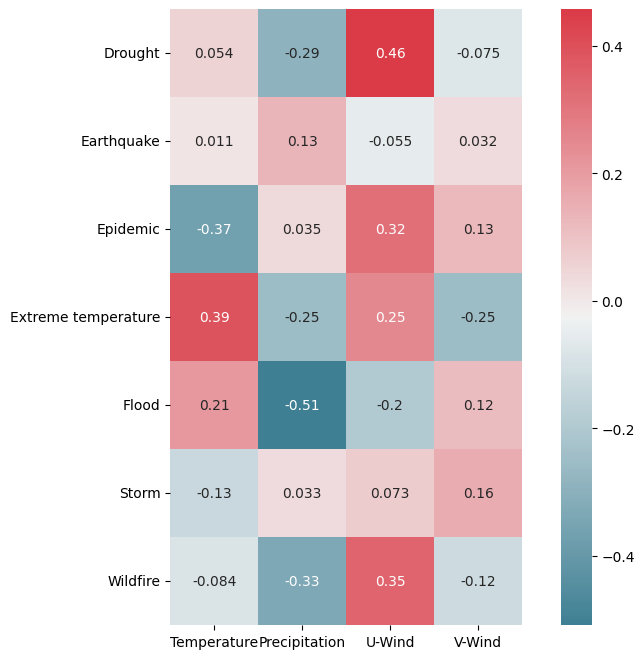

In [14]:
X = dfYearTypeWeath.iloc[:, 1:]
corr = X.corr()

corr = corr.loc[['Drought', 'Earthquake', 'Epidemic',
       'Extreme temperature', 'Flood','Storm', 'Wildfire'],
    ['Temperature', 'Precipitation', 'U-Wind', 'V-Wind']]

display(corr)

f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True), square=True, ax=ax, annot=True)

In [15]:
disaster_type_columns = ['Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']
df_melted = dfYearTypeWeath.melt(id_vars='Year', value_vars=disaster_type_columns, var_name='Disaster Type', value_name='Count')

fig = px.bar(df_melted, x='Year', y='Count', color='Disaster Type',
             title='Number of Disasters by Type Each Year')
fig.show()

In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

dfWeather_sa['Datetime'] = pd.to_datetime(dfWeather_sa[['Year', 'Month', 'Day', 'Hour']])
dfWeather_sa['Wind_Magnitude'] = np.sqrt(dfWeather_sa['U-Wind']**2 + dfWeather_sa['V-Wind']**2)
dfWeather_sa = dfWeather_sa.set_index('Datetime')

# Resample to yearly averages for Milnerton-South Africa
df_yearly = dfWeather_sa[['Temperature', 'Precipitation', 'Wind_Magnitude']].resample('YE').mean()
df_yearly = df_yearly.reset_index()

# Ensure 'Total_Event_Count' is calculated in dfYearTypeWeath (if not already)
# This check is for robustness; the column should exist from previous steps
if 'Total_Event_Count' not in dfYearTypeWeath.columns:
    disaster_type_columns = ['Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']
    dfYearTypeWeath['Total_Event_Count'] = dfYearTypeWeath[disaster_type_columns].sum(axis=1)

# Extract year from df_yearly for merging
df_yearly['Year'] = df_yearly['Datetime'].dt.year

# Merge df_yearly with total event count from dfYearTypeWeath
df_merged = pd.merge(df_yearly, dfYearTypeWeath[['Year', 'Total_Event_Count']], on='Year', how='left')

# Fill NaN Total_Event_Count for years where global disaster data is not available
df_merged['Total_Event_Count'] = df_merged['Total_Event_Count'].fillna(0)

# Plotting yearly aggregates with overlaid total event count
# Plot 1: Temperature
fig_temp_yearly = make_subplots(specs=[[{'secondary_y': True}]])
fig_temp_yearly.add_trace(
    go.Bar(x=df_merged['Datetime'], y=df_merged['Total_Event_Count'], name='Total Event Count'),
    secondary_y=False,
)
fig_temp_yearly.add_trace(
    go.Scatter(x=df_merged['Datetime'], y=df_merged['Temperature'], name='Temperature (K)', mode='lines'),
    secondary_y=True,
)
fig_temp_yearly.update_layout(
    title_text='Yearly Average Temperature (Milnerton-SA) with Global Total Event Count',
    xaxis_title='Year'
)
fig_temp_yearly.update_yaxes(title_text='Global Total Event Count', secondary_y=False)
fig_temp_yearly.update_yaxes(title_text='Temperature (K)', secondary_y=True)
fig_temp_yearly.show()

# Plot 2: Precipitation
fig_precip_yearly = make_subplots(specs=[[{'secondary_y': True}]])
fig_precip_yearly.add_trace(
    go.Bar(x=df_merged['Datetime'], y=df_merged['Total_Event_Count'], name='Total Event Count'),
    secondary_y=False,
)
fig_precip_yearly.add_trace(
    go.Scatter(x=df_merged['Datetime'], y=df_merged['Precipitation'], name='Precipitation (kg m-2 s-1)', mode='lines'),
    secondary_y=True,
)
fig_precip_yearly.update_layout(
    title_text='Yearly Average Precipitation (Milnerton-SA) with Global Total Event Count',
    xaxis_title='Year'
)
fig_precip_yearly.update_yaxes(title_text='Global Total Event Count', secondary_y=False)
fig_precip_yearly.update_yaxes(title_text='Precipitation (kg m-2 s-1)', secondary_y=True)
fig_precip_yearly.show()

# Plot 3: Wind Magnitude
fig_wind_yearly = make_subplots(specs=[[{'secondary_y': True}]])
fig_wind_yearly.add_trace(
    go.Bar(x=df_merged['Datetime'], y=df_merged['Total_Event_Count'], name='Total Event Count'),
    secondary_y=False,
)
fig_wind_yearly.add_trace(
    go.Scatter(x=df_merged['Datetime'], y=df_merged['Wind_Magnitude'], name='Wind Magnitude (m/s)', mode='lines'),
    secondary_y=True,
)
fig_wind_yearly.update_layout(
    title_text='Yearly Average Wind Magnitude (Milnerton-SA) with Global Total Event Count',
    xaxis_title='Year'
)
fig_wind_yearly.update_yaxes(title_text='Global Total Event Count', secondary_y=False)
fig_wind_yearly.update_yaxes(title_text='Wind Magnitude (m/s)', secondary_y=True)
fig_wind_yearly.show()

In [20]:
malaria_df = pd.read_csv("/content/drive/MyDrive/ADS_CW_Data/malaria_cases_p1000_at_risk.csv")

def clean_malaria_data(df):
    df = df.copy()

    df = df[['Location', 'Period', 'FactValueNumeric']]

    df = df.rename(columns={
        'Location': 'country',
        'Period': 'year',
        'FactValueNumeric': 'malaria_incidence'
    })

    # Convert types first
    df['year'] = df['year'].astype(int)
    df['malaria_incidence'] = pd.to_numeric(df['malaria_incidence'], errors='coerce')

    # DO NOT DROP NaNs — replace with 0
    df['malaria_incidence'] = df['malaria_incidence'].fillna(0)

    return df


malaria = clean_malaria_data(malaria_df)

# Create malaria_sa dataframe
malaria_sa = malaria[malaria['country'] == 'South Africa'].copy()
malaria_sa.head()

,country,year,malaria_incidence
31,South Africa,2024,0.11
146,South Africa,2023,0.84
246,South Africa,2022,0.33
352,South Africa,2021,0.48
460,South Africa,2020,0.74


In [21]:
dfYearTypeWeath = pd.merge(dfYearTypeWeath, malaria_sa[['year', 'malaria_incidence']], left_on='Year', right_on='year', how='left')
dfYearTypeWeath = dfYearTypeWeath.drop(columns=['year']) # Drop the redundant 'year' column after merging

display(dfYearTypeWeath.head())

,Year,Drought,Earthquake,Epidemic,Extreme temperature,Flood,Storm,Wildfire,Temperature,Precipitation,U-Wind,V-Wind,Total_Event_Count,malaria_incidence
0,2000,0.0,0.0,1.0,0.0,2.0,1.0,1.0,285.377688,0.000094,0.738356,0.059835,5.0,3.86
1,2001,0.0,0.0,0.0,0.0,2.0,2.0,2.0,285.725688,0.000083,0.638282,-0.074205,6.0,5.57
2,2002,0.0,0.0,3.0,0.0,1.0,4.0,1.0,285.572416,0.000097,0.733261,0.078387,9.0,3.26
3,2003,0.0,0.0,0.0,0.0,1.0,1.0,0.0,285.523856,0.000093,0.529678,0.002898,2.0,2.78
4,2004,1.0,0.0,1.0,0.0,1.0,0.0,0.0,285.227019,0.000092,0.772114,-0.128373,3.0,2.73


,malaria_incidence
Drought,0.116123
Earthquake,-0.110732
Epidemic,0.270555
Extreme temperature,-0.349231
Flood,0.378479
Storm,0.513166
Wildfire,0.716936


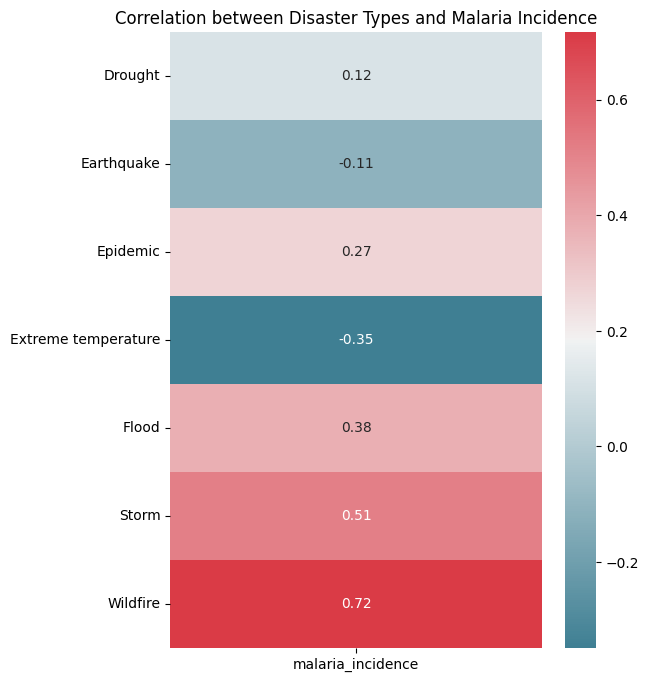

In [22]:
disaster_type_columns = ['Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']
correlation_columns = disaster_type_columns + ['malaria_incidence']

# Create a subset DataFrame for correlation calculation
df_correlation_malaria = dfYearTypeWeath[correlation_columns]

# Calculate the correlation matrix
corr_malaria = df_correlation_malaria.corr()

# Extract the correlation of disaster types with malaria incidence
malaria_disaster_corr = corr_malaria.loc[disaster_type_columns, ['malaria_incidence']]

display(malaria_disaster_corr)

# Plotting the correlation using a heatmap
f, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(malaria_disaster_corr, cmap=sns.diverging_palette(220, 10, as_cmap=True), annot=True, fmt=".2f", ax=ax)
ax.set_title('Correlation between Disaster Types and Malaria Incidence')
plt.show()

,malaria_incidence
Temperature,-0.217886
Precipitation,-0.073281
Wind_Magnitude,0.037134


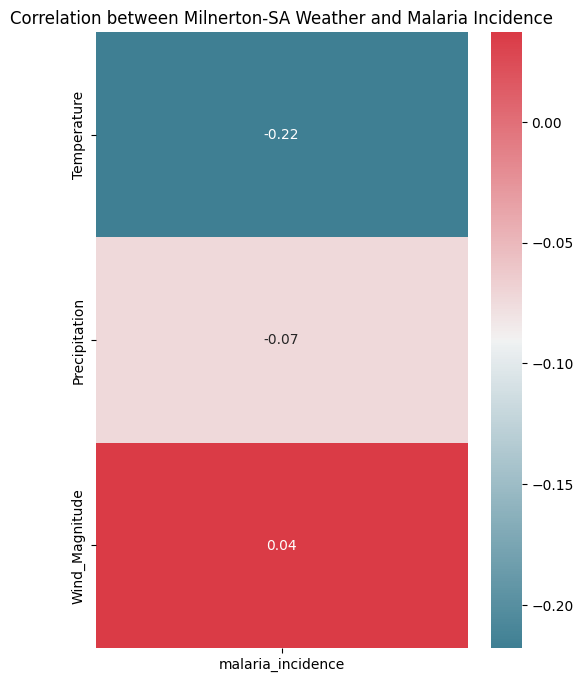

In [23]:
# Merge df_yearly (Milnerton-SA weather) with malaria_sa (South Africa malaria incidence)
df_weather_malaria = pd.merge(df_yearly, malaria_sa[['year', 'malaria_incidence']], left_on='Year', right_on='year', how='inner')
df_weather_malaria = df_weather_malaria.drop(columns=['year']) # Drop redundant 'year' column from malaria_sa

# Select relevant columns for correlation
correlation_columns_weather = ['Temperature', 'Precipitation', 'Wind_Magnitude', 'malaria_incidence']
df_correlation_weather = df_weather_malaria[correlation_columns_weather]

# Calculate correlation matrix
corr_weather_malaria = df_correlation_weather.corr()

# Extract correlations of weather variables with malaria_incidence
malaria_weather_corr = corr_weather_malaria.loc[['Temperature', 'Precipitation', 'Wind_Magnitude'], ['malaria_incidence']]

display(malaria_weather_corr)

# Plotting the correlation using a heatmap
f, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(malaria_weather_corr, cmap=sns.diverging_palette(220, 10, as_cmap=True), annot=True, fmt=".2f", ax=ax)
ax.set_title('Correlation between Milnerton-SA Weather and Malaria Incidence')
plt.show()

In [24]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

disaster_type_columns = ['Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']
df_melted = dfYearTypeWeath.melt(id_vars='Year', value_vars=disaster_type_columns, var_name='Disaster Type', value_name='Count')

# Create subplots with secondary y-axis
fig = make_subplots(specs=[[{'secondary_y': True}]])

# Add bar chart for disaster counts
for disaster_type in disaster_type_columns:
    df_subset = df_melted[df_melted['Disaster Type'] == disaster_type]
    fig.add_trace(
        go.Bar(x=df_subset['Year'], y=df_subset['Count'], name=disaster_type, legendgroup='disasters'),
        secondary_y=False,
    )

# Add line plot for malaria incidence
fig.add_trace(
    go.Scatter(x=dfYearTypeWeath['Year'], y=dfYearTypeWeath['malaria_incidence'], name='Malaria Incidence', mode='lines+markers', line=dict(color='red')),
    secondary_y=True,
)

# Update layout and titles
fig.update_layout(
    title_text='Number of Disasters by Type and Malaria Incidence Each Year',
    xaxis_title='Year'
)
fig.update_yaxes(title_text='Number of Disasters', secondary_y=False)
fig.update_yaxes(title_text='Malaria Incidence', secondary_y=True)

fig.show()

In [25]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

disaster_type_columns = ['Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']
df_melted = dfYearTypeWeath.melt(id_vars='Year', value_vars=disaster_type_columns, var_name='Disaster Type', value_name='Count')

# Create subplots with secondary y-axis
fig = make_subplots(specs=[[{'secondary_y': True}]])

# Add bar chart for disaster counts
for disaster_type in disaster_type_columns:
    df_subset = df_melted[df_melted['Disaster Type'] == disaster_type]
    fig.add_trace(
        go.Bar(x=df_subset['Year'], y=df_subset['Count'], name=disaster_type, legendgroup='disasters'),
        secondary_y=False,
    )

# Add line plot for malaria incidence
fig.add_trace(
    go.Scatter(x=dfYearTypeWeath['Year'], y=dfYearTypeWeath['malaria_incidence'], name='Malaria Incidence', mode='lines+markers', line=dict(color='red')),
    secondary_y=True,
)

# Update layout and titles
fig.update_layout(
    title_text='Number of Disasters by Type and Malaria Incidence Each Year',
    xaxis_title='Year',
    barmode='stack' # Set barmode to 'stack' for stacked bars
)
fig.update_yaxes(title_text='Number of Disasters', secondary_y=False)
fig.update_yaxes(title_text='Malaria Incidence', secondary_y=True)

fig.show()

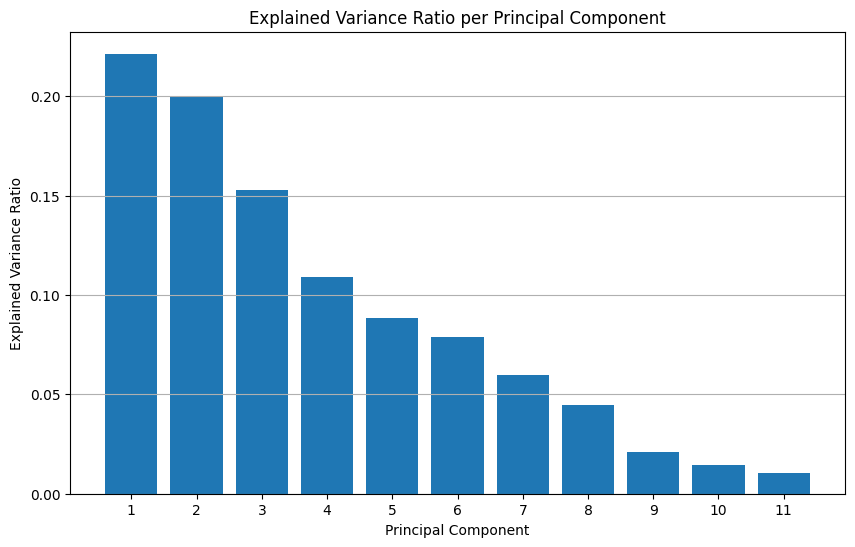

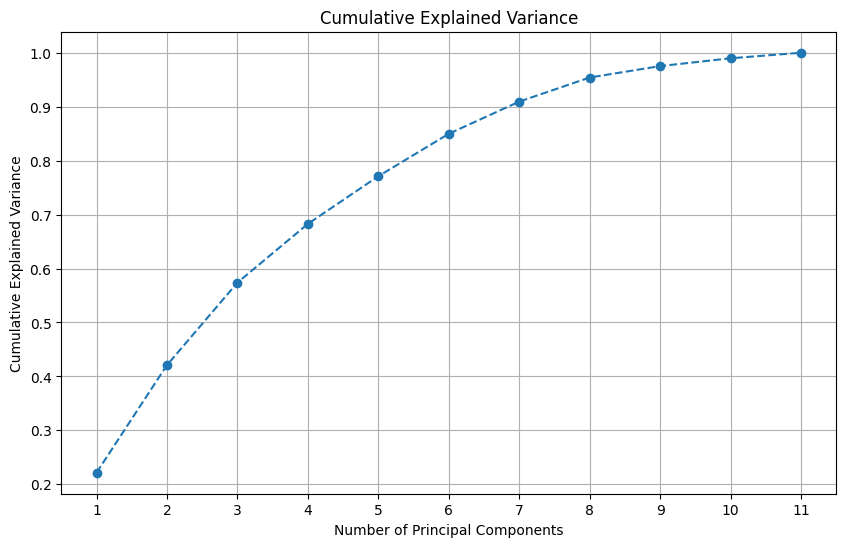

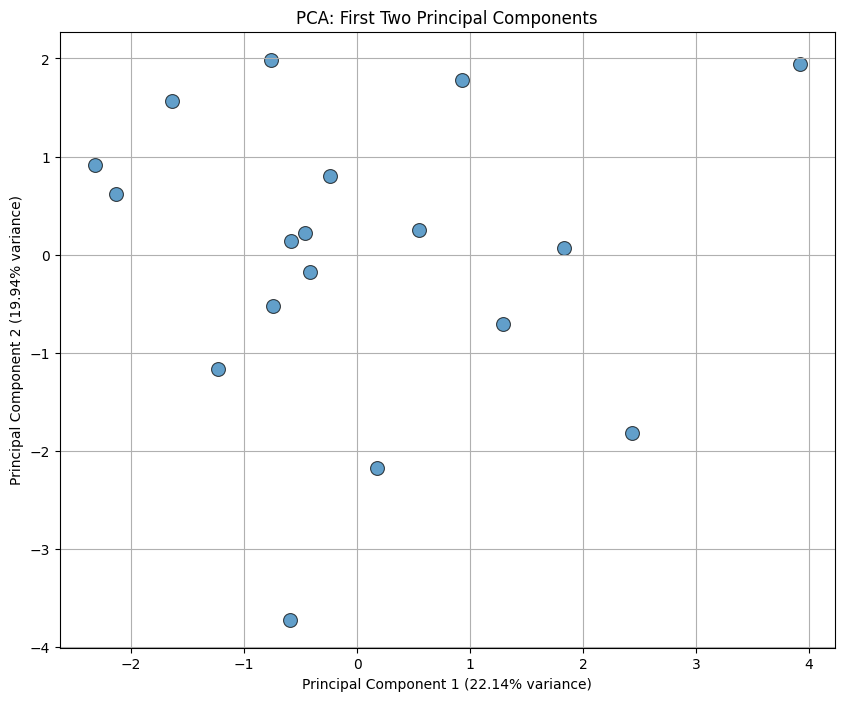

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,1.829394,0.070262,-0.454265,-0.280875,0.170314,0.626271,-1.345696,-0.559192,0.014996,0.147546,-0.339383
1,2.430315,-1.823307,-0.968702,-0.495712,-0.822926,1.801071,1.011008,-0.917994,-0.475172,-0.212476,-0.109589
2,3.915825,1.941197,-0.561138,0.204852,1.203272,-0.251588,0.494053,1.683949,-0.093753,-0.180841,0.028943
3,-0.581703,0.142929,-0.888697,-0.087401,-1.121413,0.187031,-0.172186,0.313424,-0.939869,-0.183799,0.154080
4,0.545463,0.253285,2.686217,-0.217003,-1.419366,0.547713,-1.716994,0.774970,0.110601,0.090996,0.111034


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Drought,0.067109,-0.066545,0.595896,0.417994,-0.342462,0.038292,-0.040318,0.065892,0.361001,-0.108839,0.440881
Earthquake,-0.323121,0.123656,0.048788,-0.027539,0.512568,0.698882,0.095069,0.141485,0.134319,0.091437,0.265598
Epidemic,0.460468,0.269457,0.014744,-0.021204,0.238062,-0.021768,-0.245961,0.630058,0.215199,-0.327222,-0.216084
Extreme temperature,-0.030244,-0.475575,0.070258,-0.353915,0.392433,-0.407206,-0.095466,0.130680,-0.082870,-0.165012,0.512458
Flood,0.240384,-0.372987,-0.434602,0.024591,-0.097826,0.171579,-0.437550,-0.031123,0.439246,0.425541,0.090346
Storm,0.478708,0.244355,-0.196002,0.086980,-0.004409,-0.081492,0.496814,0.168251,-0.193851,0.402654,0.428539
Wildfire,0.502181,-0.117412,-0.017899,-0.199564,0.096899,0.267938,0.271501,-0.545413,0.201504,-0.448226,0.001928
Temperature,-0.126167,-0.451158,-0.111711,0.381348,0.201438,-0.154193,0.556279,0.208989,0.311200,-0.015989,-0.328718
Precipitation,-0.216499,0.493838,-0.070980,-0.174217,0.154885,-0.428740,0.072743,-0.236224,0.623467,0.097816,0.081749
U-Wind,0.274838,-0.057921,0.567202,0.025992,0.424939,-0.088614,-0.115999,-0.222473,-0.062084,0.498980,-0.307416


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns for PCA (disaster types and weather metrics)
disaster_type_columns = ['Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']
weather_columns = ['Temperature', 'Precipitation', 'U-Wind', 'V-Wind']

# Combine all relevant columns
pca_columns = disaster_type_columns + weather_columns

df_pca = dfYearTypeWeath[pca_columns].copy()

# Handle potential missing values (if any) by dropping rows.
# For this dataset, we expect no NaNs in these columns after previous merges and processing.
df_pca = df_pca.dropna()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# Perform PCA
pca = PCA()
pca.fit(X_scaled)

# Create a DataFrame for the principal components
pca_df = pd.DataFrame(data=pca.transform(X_scaled), columns=[f'PC{i+1}' for i in range(pca.n_components_)])

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio per Principal Component')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(axis='y')
plt.show()

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(True)
plt.show()

# Visualize the first two principal components (if n_components > 1)
if pca.n_components_ >= 2:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='PC1',
        y='PC2',
        data=pca_df,
        s=100,  # size of points
        edgecolor='k', # black edge for points
        alpha=0.7 # transparency
    )
    plt.title('PCA: First Two Principal Components')
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
    plt.grid(True)
    plt.show()
else:
    print("Not enough components to plot PC1 vs PC2.")

display(pca_df.head())

# Optionally, display the loadings (eigenvectors) to understand feature contributions
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=pca_columns)
display(loadings)

### Regression Analysis: Predicting Malaria Incidence with Principal Components

Based on the cumulative explained variance plot from the PCA, retaining the first **3 principal components** (PC1, PC2, PC3) seems like a reasonable choice as they capture a significant portion of the total variance. We will now use these 3 components as features to predict `malaria_incidence` using a linear regression model.

Linear Regression Model Performance (using 3 PCs):

R-squared: 0.007
Mean Squared Error (MSE): 2.849
Root Mean Squared Error (RMSE): 1.688

Model Coefficients (Loadings for Malaria Incidence prediction):


,Coefficient
PC1,0.334809
PC2,0.139418
PC3,0.004643


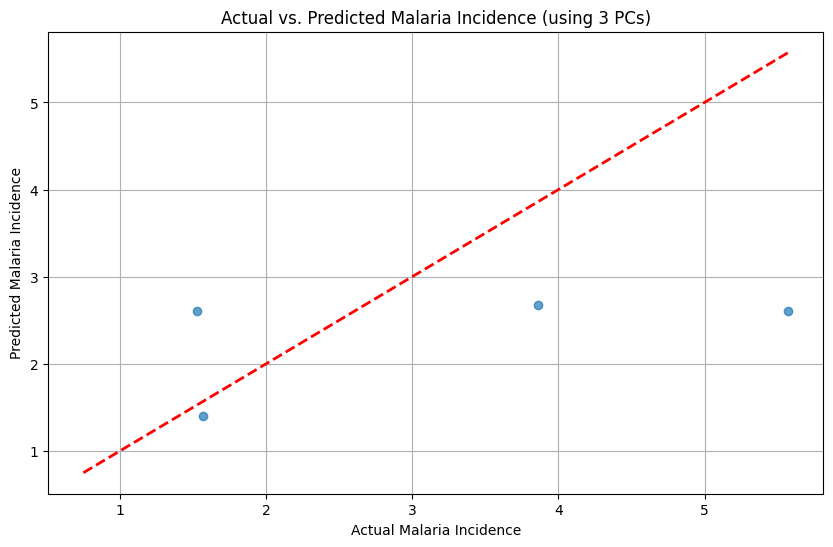

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Combine the first 3 principal components with malaria_incidence
# First, align the pca_df with dfYearTypeWeath based on the rows used for PCA

# Create a temporary DataFrame that includes 'Year' and 'malaria_incidence' from the original dfYearTypeWeath
# and then drop NA rows that correspond to the df_pca creation
df_for_regression_base = dfYearTypeWeath[['Year', 'malaria_incidence'] + pca_columns].copy()
df_for_regression_base = df_for_regression_base.dropna(subset=pca_columns) # Ensure same rows as used for PCA

# Now, the index of pca_df corresponds to the filtered df_for_regression_base
df_regression = pd.concat(
    [df_for_regression_base[['Year', 'malaria_incidence']].reset_index(drop=True),
     pca_df.iloc[:, :3].reset_index(drop=True)],
    axis=1
)

# Ensure malaria_incidence is not NaN for the regression target
df_regression = df_regression.dropna(subset=['malaria_incidence'])

# Define features (X) and target (y)
X = df_regression[['PC1', 'PC2', 'PC3']]
y = df_regression['malaria_incidence']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Linear Regression Model Performance (using 3 PCs):\n")
print(f"R-squared: {r2:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print("\nModel Coefficients (Loadings for Malaria Incidence prediction):")
coefficients = pd.DataFrame(model.coef_, index=X.columns, columns=['Coefficient'])
display(coefficients)

# Plotting actual vs. predicted values for a visual check
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Identity line
plt.xlabel('Actual Malaria Incidence')
plt.ylabel('Predicted Malaria Incidence')
plt.title('Actual vs. Predicted Malaria Incidence (using 3 PCs)')
plt.grid(True)
plt.show()